Helmet Detection using Faster R-CNN

1. Import Libraries
2. GPU Control
3. Dataset Paths
4. Load COCO Dataset
5. DataLoader
6. Load Faster R-CNN
7. Train Model
8. Plot Loss over Epoch
9. Evaluate Model
10. Confusion Matrix
11. Accuracy / mAP Table

In [16]:
%pip install scikit-learn

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 660.6 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 650.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/8.3 MB 3.2 MB/s eta 0:00:03
    --------------------------------------- 0.2/8.3 MB 2.1 MB/s eta 0:00:04
   - -------------------------------------- 0.3/8.3 MB 1.8 MB/s eta 0:00:05
   -- ------------------------------------- 0.4/8.3 MB 2.4 MB/s eta 0:00:04
   -- ------------------------------------- 0.6/8.3 MB 2.5 MB/s eta 0:00:04
   --- ------------------------------------ 0.7/8.3 MB 2.7 MB/s eta 0:00:03
   ---- ----------------------------------- 0.9/8.3 MB 2.9 MB/s eta 0:00:03
   ---- ----------------------------------- 1.0/8.3 MB 2.9 MB/s eta 0:00:03
   ----- ---------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms.v2 as T

from torch.utils.data import DataLoader
from torchvision.datasets import CocoDetection
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
train_loss_history = []

precision_history = []
recall_history = []
map50_history = []
map5095_history = []

epoch_times = []

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
NVIDIA GeForce RTX 3050 Laptop GPU


In [9]:
train_images = "fasterrcnn_dataset/train"
train_annotations = "fasterrcnn_dataset/train/_annotations.coco.json"

valid_images = "fasterrcnn_dataset/valid"
valid_annotations = "fasterrcnn_dataset/valid/_annotations.coco.json"

In [10]:
!pip install pycocotools


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from torchvision.transforms import v2 as T

In [13]:
transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])

In [17]:
train_dataset = CocoDetection(
    root=train_images,
    annFile=train_annotations,
    transforms=transform
)

valid_dataset = CocoDetection(
    root=valid_images,
    annFile=valid_annotations,
    transforms=transform
)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [18]:
print(len(train_dataset))
print(len(valid_dataset))

831
398


In [19]:
def collate_fn(batch):
    return tuple(zip(*batch))

# DataLoader'ları oluşturuyoruz (Resimleri dörderli gruplar halinde modele besleyecek)
train_loader = DataLoader(
    train_dataset, 
    batch_size=4, 
    shuffle=True, 
    num_workers=0, # Windows'ta hata vermemesi için 0 yaptık aşko
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset, 
    batch_size=4, 
    shuffle=False, 
    num_workers=0, 
    collate_fn=collate_fn
)

print(f"Train loader adım sayısı: {len(train_loader)}")
print(f"Valid loader adım sayısı: {len(valid_loader)}")

Train loader adım sayısı: 208
Valid loader adım sayısı: 100


In [20]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 1. Hazır eğitilmiş Faster R-CNN modelini kütüphaneden indiriyoruz
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

# 2. Modelin son katmanındaki giriş özellik (feature) sayısını alıyoruz
in_features = model.roi_heads.box_predictor.cls_score.in_features

# 3. Sınıf sayımızı belirliyoruz: 2 nesne sınıfı (kafa, kask) + 1 Arka Plan (Background) = 3
num_classes = 3 

# 4. Modelin kutu tahmin kafasını kendi sınıf sayımıza göre değiştiriyoruz
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# 5. Modeli o güçlü ekran kartına (GPU/cuda) gönderiyoruz
model.to(device)

print("Faster R-CNN modeli başarıyla yüklendi ve GPU'ya taşındı! 🚀")

Faster R-CNN modeli başarıyla yüklendi ve GPU'ya taşındı! 🚀


In [22]:
import torch.optim as optim

# Modelin güncellenecek ağırlıklarını (parametrelerini) seçiyoruz
params = [p for p in model.parameters() if p.requires_grad]

# Optimizer (SGD) ve öğrenme oranı (Learning Rate) ayarları
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# Öğrenme oranını her 3 epochta bir %10'una düşürerek eğitimin daha hassas olmasını sağlar (Scheduler)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Loss değerlerini grafik çizdirmek için kaydedeceğimiz boş liste
train_loss_history = []

print("Optimizer ve eğitim ayarları başarıyla tamamlandı! 🛠️")

Optimizer ve eğitim ayarları başarıyla tamamlandı! 🛠️


In [ ]:
import time

num_epochs = 100

for epoch in range(num_epochs):
    model.train()  
    epoch_loss = 0
    start_time = time.time()
    
    for images, targets in train_loader:
        # Resimleri ekran kartına (GPU) gönderiyoruz
        images = list(image.to(device) for image in images)
        
        # COCO formatındaki etiketleri Faster R-CNN'in istediği formata [x1, y1, x2, y2] çeviriyoruz
        processed_targets = []
        for target in targets:
            boxes = []
            labels = []
            for t in target:
                x, y, w, h = t['bbox']
                boxes.append([x, y, x + w, y + h])
                labels.append(t['category_id'])
            
            if len(boxes) == 0:
                boxes = torch.zeros((0, 4), dtype=torch.float32)
                labels = torch.zeros((0,), dtype=torch.int64)
            else:
                boxes = torch.tensor(boxes, dtype=torch.float32)
                labels = torch.tensor(labels, dtype=torch.int64)
                
            processed_targets.append({"boxes": boxes.to(device), "labels": labels.to(device)})
            
        # Modeli ileri besliyoruz ve hata (loss) oranlarını alıyoruz
        loss_dict = model(images, processed_targets)
        losses = sum(loss for loss in loss_dict.values())
        
        # Geri yayılım (Backpropagation) ile ağırlıkları güncelliyoruz
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        epoch_loss += losses.item()
        

    lr_scheduler.step()
    
    avg_loss = epoch_loss / len(train_loader)
    train_loss_history.append(avg_loss)
  
    
    end_time = time.time()
    epoch_time = end_time - start_time
    epoch_times.append(epoch_time)
    print(f"Epoch [{epoch+1}/{num_epochs}] Bitti! -> Ortalama Loss: {avg_loss:.4f} | Süre: {end_time - start_time:.2f} saniye")

import os

folder_name = "faster_rcnn_100e"
os.makedirs(folder_name, exist_ok=True)

save_path = os.path.join(folder_name, "best.pth")
torch.save(model.state_dict(), save_path)

print(f"Eğitim Tamamlandı ve '{save_path}' olarak kaydedildi! ")

Epoch [1/100] Bitti! -> Ortalama Loss: 0.5802 | Süre: 174.82 saniye
Epoch [2/100] Bitti! -> Ortalama Loss: 0.3947 | Süre: 174.59 saniye
Epoch [3/100] Bitti! -> Ortalama Loss: 0.3450 | Süre: 174.97 saniye
Epoch [4/100] Bitti! -> Ortalama Loss: 0.2752 | Süre: 172.58 saniye
Epoch [5/100] Bitti! -> Ortalama Loss: 0.2620 | Süre: 172.63 saniye
Epoch [6/100] Bitti! -> Ortalama Loss: 0.2549 | Süre: 172.01 saniye
Epoch [7/100] Bitti! -> Ortalama Loss: 0.2467 | Süre: 172.06 saniye
Epoch [8/100] Bitti! -> Ortalama Loss: 0.2445 | Süre: 175.00 saniye
Epoch [9/100] Bitti! -> Ortalama Loss: 0.2449 | Süre: 172.93 saniye
Epoch [10/100] Bitti! -> Ortalama Loss: 0.2433 | Süre: 170.54 saniye
Epoch [11/100] Bitti! -> Ortalama Loss: 0.2434 | Süre: 168.68 saniye
Epoch [12/100] Bitti! -> Ortalama Loss: 0.2434 | Süre: 169.24 saniye
Epoch [13/100] Bitti! -> Ortalama Loss: 0.2434 | Süre: 171.33 saniye
Epoch [14/100] Bitti! -> Ortalama Loss: 0.2424 | Süre: 171.70 saniye
Epoch [15/100] Bitti! -> Ortalama Loss: 0.2

In [28]:
from pycocotools.cocoeval import COCOeval

model.eval()
cocoGt = valid_dataset.coco
cocoDt = []

all_true = []
all_pred = []

with torch.no_grad():

    image_ids = []

    for images, targets in valid_loader:

        images = [img.to(device) for img in images]

        outputs = model(images)

        for output, target in zip(outputs, targets):

            image_id = int(target[0]["image_id"])

            image_ids.append(image_id)

            boxes = output["boxes"].cpu().numpy()
            scores = output["scores"].cpu().numpy()
            labels = output["labels"].cpu().numpy()

            for box, score, label in zip(boxes, scores, labels):

                x1,y1,x2,y2 = box

                cocoDt.append({
                    "image_id": int(image_id),
                    "category_id": int(label),
                    "bbox":[
                        float(x1),
                        float(y1),
                        float(x2-x1),
                        float(y2-y1)
                    ],
                    "score": float(score)
                })

            gt_labels = [int(t["category_id"]) for t in target]
            pred_labels=list(labels)

            all_true.extend(gt_labels)

            if len(pred_labels)==0:
                pred_labels=[0]*len(gt_labels)

            all_pred.extend(pred_labels[:len(gt_labels)])
            min_len = min(len(all_true), len(all_pred))
            all_true = all_true[:min_len]
            all_pred = all_pred[:min_len]

In [30]:
from pycocotools.cocoeval import COCOeval

cocoDt = cocoGt.loadRes(cocoDt)

cocoEval = COCOeval(cocoGt, cocoDt, "bbox")
cocoEval.params.imgIds = image_ids

cocoEval.evaluate()
cocoEval.accumulate()
cocoEval.summarize()

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.39s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.552
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.873
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.648
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.410
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.637
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.664
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.162
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.591
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.619
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

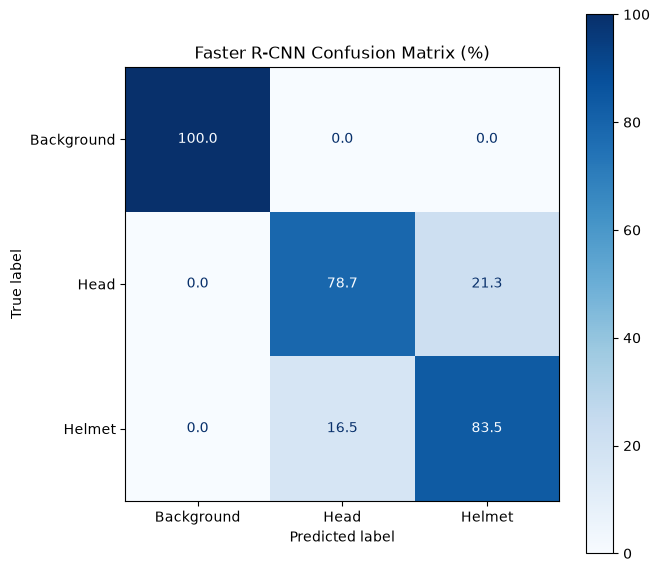


Confusion Matrix (%)
[[100.     0.     0.  ]
 [  0.    78.69  21.31]
 [  0.    16.52  83.48]]


: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

true_labels = [int(x) for x in all_true]
pred_labels = [int(x) for x in all_pred]

true_labels_fixed = []
pred_labels_fixed = []

for t, p in zip(true_labels, pred_labels):

    if p == 0:
        true_labels_fixed.append(0)
        pred_labels_fixed.append(0)
    else:
        true_labels_fixed.append(t)
        pred_labels_fixed.append(p)

cm = confusion_matrix(
    true_labels_fixed,
    pred_labels_fixed,
    labels=[0,1,2]
)

cm_percent = cm.astype(float)
row_sum = cm_percent.sum(axis=1)

for i in range(len(row_sum)):
    if row_sum[i] != 0:
        cm_percent[i] = cm_percent[i] / row_sum[i] * 100

fig, ax = plt.subplots(figsize=(7,7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent,
    display_labels=[
        "Background",
        "Head",
        "Helmet"
    ]
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".1f",
    colorbar=True
)

plt.title("Faster R-CNN Confusion Matrix (%)")
plt.savefig("confusion_matrix_percent.png", dpi=300)
plt.show()

print("\nConfusion Matrix (%)")
print(np.round(cm_percent,2))

In [1]:
import matplotlib.pyplot as plt

# 100 epochluk loss grafiğini çizdir ve kaydet
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_loss_history) + 1), train_loss_history, color='#1f77b4', linewidth=2, label='Training Total Loss')
plt.title('Faster R-CNN Training Loss Convergence (100 Epochs)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Loss Value', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

# Makaleye eklenecek resmi kaydet
plt.savefig('faster_rcnn_loss.png', dpi=300)
plt.show()
print("Grafik 'faster_rcnn_loss.png' olarak başarıyla kaydedildi!")

NameError: name 'train_loss_history' is not defined

<Figure size 800x500 with 0 Axes>

In [5]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 1. Modeli oluştur
model = fasterrcnn_resnet50_fpn(weights=None)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=3)

# 2. Katmanları listele
print("=== Katman Listesi ===")
for name, module in model.named_modules():
    if name.startswith("backbone.body.layer") or name.startswith("backbone.fpn"):
        print(name)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\hp/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:38<00:00, 2.65MB/s]


=== Katman Listesi ===
backbone.body.layer1
backbone.body.layer1.0
backbone.body.layer1.0.conv1
backbone.body.layer1.0.bn1
backbone.body.layer1.0.conv2
backbone.body.layer1.0.bn2
backbone.body.layer1.0.conv3
backbone.body.layer1.0.bn3
backbone.body.layer1.0.relu
backbone.body.layer1.0.downsample
backbone.body.layer1.0.downsample.0
backbone.body.layer1.0.downsample.1
backbone.body.layer1.1
backbone.body.layer1.1.conv1
backbone.body.layer1.1.bn1
backbone.body.layer1.1.conv2
backbone.body.layer1.1.bn2
backbone.body.layer1.1.conv3
backbone.body.layer1.1.bn3
backbone.body.layer1.1.relu
backbone.body.layer1.2
backbone.body.layer1.2.conv1
backbone.body.layer1.2.bn1
backbone.body.layer1.2.conv2
backbone.body.layer1.2.bn2
backbone.body.layer1.2.conv3
backbone.body.layer1.2.bn3
backbone.body.layer1.2.relu
backbone.body.layer2
backbone.body.layer2.0
backbone.body.layer2.0.conv1
backbone.body.layer2.0.bn1
backbone.body.layer2.0.conv2
backbone.body.layer2.0.bn2
backbone.body.layer2.0.conv3
backbone

Kullanılan Cihaz: cuda
Görsel kaydedildi: fasterrcnn_eigencam_fpn.jpg


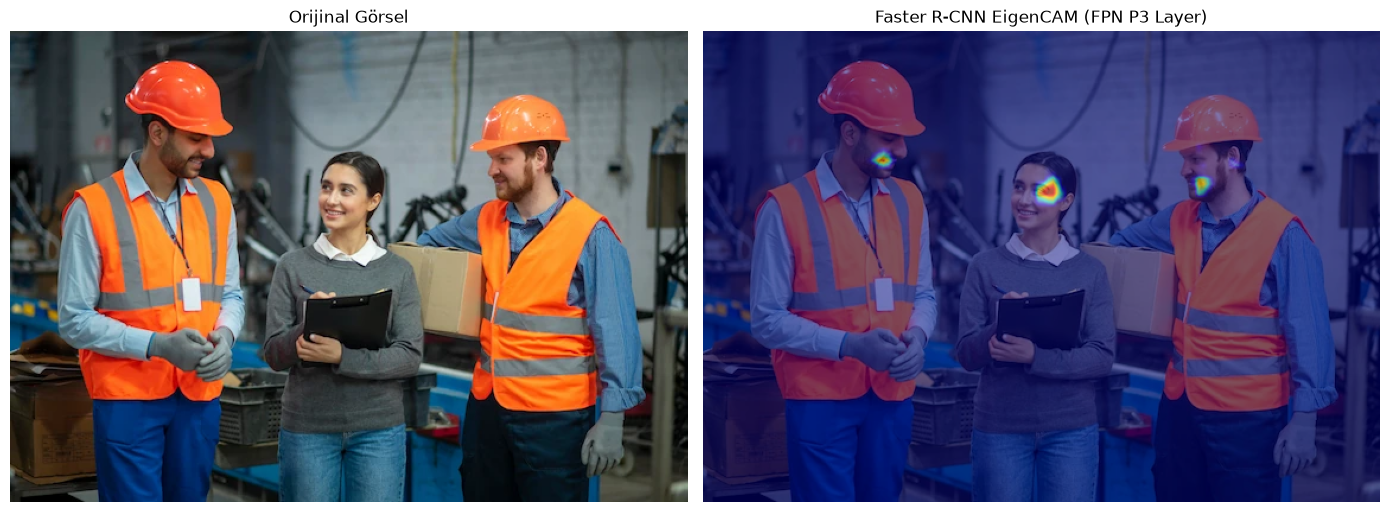

In [8]:
%matplotlib inline
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.v2 as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 1. Cihaz ve Model Kurulumu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan Cihaz: {device}")

model = fasterrcnn_resnet50_fpn(weights=None)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=3)

# Eğitilmiş ağırlığı yükle[cite: 2]
weights_path = "faster_rcnn_100e/best.pth"
model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()

# 2. Hedef Katman (FPN P3 / layer_blocks[1] - Baret tespiti için ideal)
target_layer = model.backbone.fpn.layer_blocks[1]

activations = {}
def hook_fn(module, input, output):
    activations['feat'] = output

hook_handle = target_layer.register_forward_hook(hook_fn)

# 3. Test Görseli Yükleme ve Dönüştürme
image_path = "saha.webp"  # Test etmek istediğin baretli görselin yolu
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError(f"Görsel bulunamadı: {image_path}")

orig_h, orig_w = img_bgr.shape[:2]
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])
input_tensor = transform(img_rgb).unsqueeze(0).to(device)

# 4. Modeli İleri Besleme (Inference)
with torch.no_grad():
    _ = model(input_tensor)

hook_handle.remove()

# 5. EigenCAM Hesabı (Doğru SVD Boyutlandırması)
act = activations['feat']
if isinstance(act, (list, tuple)):
    act = act[0]

# [1, C, H, W] -> SVD için [C, H*W]
_, c, h, w = act.shape
act_matrix = act.squeeze(0).reshape(c, h * w).float()

# act_matrix: [C, H*W] matrisinde 1. temel bileşeni bul
# u: [C, 1], s: [1], v: [H*W, 1]
u, s, v = torch.svd_lowrank(act_matrix, q=1)

# v matrisi doğrudan [H*W, 1] boyutundadır
cam = v[:, 0].reshape(h, w).cpu().numpy()

# 0 - 1 arası normalizasyon
cam = np.maximum(cam, 0)
cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# 6. Isı Haritası Oluşturma ve Bindirme
cam_resized = cv2.resize(cam, (orig_w, orig_h))
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

rgb_norm = img_rgb.astype(np.float32) / 255.0
overlay = np.clip(0.5 * rgb_norm + 0.5 * heatmap_rgb, 0, 1)

# Diske kaydet
output_filename = "fasterrcnn_eigencam_fpn.jpg"
cv2.imwrite(output_filename, cv2.cvtColor((overlay * 255).astype(np.uint8), cv2.COLOR_RGB2BGR))
print(f"Görsel kaydedildi: {output_filename}")

# 7. Yan Yana Çizdir
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(img_rgb)
ax[0].set_title("Orijinal Görsel")
ax[0].axis("off")

ax[1].imshow(overlay)
ax[1].set_title("Faster R-CNN EigenCAM (FPN P3 Layer)")
ax[1].axis("off")

plt.tight_layout()
plt.show()